# Fetch Dataset

In [ ]:
# Import
import pandas as pd
import numpy as np

In [ ]:
path = "https://docs.google.com/spreadsheets/d/1kvfhinwkhRuuenwyrYCWQnmU4SZLz3v5-9ZatSZ2vzw/export?format=xlsx"

In [ ]:
xlsx = pd.ExcelFile(path)

print("--Sheets--")
print(xlsx.sheet_names)
print()

data = xlsx.parse("Form")

--Sheets--
['Form', 'Sheet1']



# Filter Columns

In [ ]:
# Display columns
data.columns

Index(['Timestamp', 'Mail', 'Consent', 'Roll', 'Age', 'Gender_1', 'Gender_2',
       'Distance_1', 'Distance_2', 'Activity', 'Social_1', 'Social_2',
       'Conversation_1', 'Conversation_2', 'Spontaneous__Activity_1',
       'Spontaneous_Activity_2', 'Meaningful_Conversation_1',
       'Meaningful_Conversation_2', 'Express_Emotion_1', 'Express_Emotion_2',
       'Discipline_1', 'Discipline_2', 'Physical_Activity_1',
       'Physical_Activity_2', 'Ambitious_1', 'Ambitious_2', 'Cleanliness_1',
       'Cleanliness_2', 'Smoke_1', 'Smoke_2', 'Drink_1', 'Drink_2',
       'Traits_In_Match', 'Bio', 'Consideration'],
      dtype='object')

In [ ]:
# Select relevant columns
frame = data[['Mail', 'Roll',
              # 'Age',
              'Gender_1', 'Gender_2',
              'Distance_1', 'Distance_2',
              'Activity',
              'Social_1', 'Social_2',
              'Conversation_1', 'Conversation_2',
              'Spontaneous__Activity_1', 'Spontaneous_Activity_2',
              'Meaningful_Conversation_1', 'Meaningful_Conversation_2',
              'Express_Emotion_1', 'Express_Emotion_2',
              'Discipline_1', 'Discipline_2',
              'Physical_Activity_1', 'Physical_Activity_2',
              'Ambitious_1', 'Ambitious_2',
              'Cleanliness_1', 'Cleanliness_2',
              'Smoke_1', 'Smoke_2',
              'Drink_1', 'Drink_2',
              # 'Traits_In_Match', 'Bio', 'Consideration'
              ]]

frame.dropna(subset=['Roll'], inplace=True)
frame = frame.astype({'Roll': 'int32'})

/tmp/ipython-input-4083197413.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame.dropna(subset=['Roll'], inplace=True)


# Categorical Columns

In [ ]:
FORBIDDEN = 20000
FORBIDDEN_GENDER = 5000

In [ ]:
encoding_columns = ['Distance_1', 'Distance_2',
                       'Smoke_1', 'Smoke_2',
                       'Drink_1', 'Drink_2',
                      ]

numerical_columns = ['Social_1', 'Social_2',
                      'Conversation_1', 'Conversation_2',
                      'Spontaneous__Activity_1', 'Spontaneous_Activity_2',
                      'Meaningful_Conversation_1', 'Meaningful_Conversation_2',
                      'Express_Emotion_1', 'Express_Emotion_2',
                      'Discipline_1', 'Discipline_2',
                      'Physical_Activity_1', 'Physical_Activity_2',
                      'Ambitious_1', 'Ambitious_2',
                      'Cleanliness_1', 'Cleanliness_2'
                      ]

bias_columns = ['Gender_1', 'Gender_2', 'Activity']

# Scoring Numerical Features

## Operation Definitions

In [ ]:
length = len(frame)

numerical_matrix = np.zeros((length, length))

trait_pairs_numerical = [
    ('Social_1', 'Social_2'),
    ('Conversation_1', 'Conversation_2'),
    ('Spontaneous__Activity_1', 'Spontaneous_Activity_2'),
    ('Meaningful_Conversation_1', 'Meaningful_Conversation_2'),
    ('Express_Emotion_1', 'Express_Emotion_2'),
    ('Discipline_1', 'Discipline_2'),
    ('Physical_Activity_1', 'Physical_Activity_2'),
    ('Ambitious_1', 'Ambitious_2'),
    ('Cleanliness_1', 'Cleanliness_2'),
]

for col1, col2 in trait_pairs_numerical:
    # Column of person A (1) → shape (N, 1)
    A = frame[col1].values.reshape(length, 1)

    # Column of person B (2) → shape (1, N)
    B = frame[col2].values.reshape(1, length)

    # Broadcast difference → N×N matrix in one shot
    diff = np.abs(A - B)

    numerical_matrix += diff


# Scoring Encoding Features

In [ ]:
# Distance

N = len(frame)

distance_map_1 = {
    "near campus": 1,
    "within 5 Km": 2,
    "within 10 Km": 3,
    "more than 10 km": 4
}

distance_map_2 = {
    "around campus": 1,
    "within 5 Km": 2,
    "within 10 Km": 3,
    "more than 10 Km": 4
}

frame["Distance_1_mapped"] = frame["Distance_1"].map(distance_map_1)
frame["Distance_2_mapped"] = frame["Distance_2"].map(distance_map_2)

A = frame["Distance_1_mapped"].values.reshape(N, 1)
B = frame["Distance_2_mapped"].values.reshape(1, N)

distance_matrix = np.abs(A - B) * 4 / 3

In [ ]:
# Smoke

N = len(frame)

smoke1_map = {
    "Never": 0,
    "Sometimes": 1,
    "Daily": 1
}

smoke2_map = {
    "yes": 1,    # they mind
    "No": 0      # they don't mind
}

frame["Smoke_1_mapped"] = frame["Smoke_1"].map(smoke1_map)
frame["Smoke_2_mapped"] = frame["Smoke_2"].map(smoke2_map)

A = frame["Smoke_1_mapped"].values.reshape(N, 1)
B = frame["Smoke_2_mapped"].values.reshape(1, N)

smoke_matrix = np.where((A == 1) & (B == 1), FORBIDDEN, 0)

In [ ]:
# Drink

N = len(frame)

drink1_map = {
    "Never": 0,
    "Sometimes": 1,
    "Daily": 1
}

drink2_map = {
    "Yes": 1,    # they mind
    "No": 0      # they don't mind
}

frame["Drink_1_mapped"] = frame["Drink_1"].map(drink1_map)
frame["Drink_2_mapped"] = frame["Drink_2"].map(drink2_map)

A = frame["Drink_1_mapped"].values.reshape(N, 1)
B = frame["Drink_2_mapped"].values.reshape(1, N)

drink_matrix = np.where((A == 1) & (B == 1), FORBIDDEN, 0)

In [ ]:
matrices_to_analyze = {
    "distance_matrix": distance_matrix,
    "drink_matrix": drink_matrix,
    "smoke_matrix": smoke_matrix
}

for matrix_name, matrix_data in matrices_to_analyze.items():
    print(f"--- Analysis for {matrix_name} ---")
    unique_values, counts = np.unique(matrix_data, return_counts=True)
    print("Unique Values:", unique_values)
    print("Counts:", counts)
    print("\n")

--- Analysis for distance_matrix ---
Unique Values: [0.         1.33333333 2.66666667 4.        ]
Counts: [329 331 155 209]


--- Analysis for drink_matrix ---
Unique Values: [    0 20000]
Counts: [964  60]


--- Analysis for smoke_matrix ---
Unique Values: [    0 20000]
Counts: [988  36]




In [ ]:
encoding_matrix = distance_matrix + smoke_matrix + drink_matrix

# Scoring Bias Features

In [ ]:
# Parse genders
frame["Gender_2_list"] = frame["Gender_2"].apply(
    lambda x: [g.strip() for g in str(x).split(",")]
)

N = len(frame)
gender_matrix = np.zeros((N, N))

gender1 = frame["Gender_1"].values
gender2_lists = frame["Gender_2_list"].values

for i in range(N):
    allowed = gender2_lists[i]  # genders person i is okay with
    for j in range(N):
        if gender1[j] not in allowed:
            gender_matrix[i, j] = FORBIDDEN_GENDER   # forbidden pairing
        else:
            gender_matrix[i, j] = 0        # allowed pairing, no cost

In [ ]:
# Parse activities
frame["Activity_list"] = frame["Activity"].apply(
    lambda x: [a.strip() for a in str(x).split(",")]
)

activity_lists = frame["Activity_list"].values
activity_matrix = np.zeros((N, N))

for i in range(N):
    setA = set(activity_lists[i])
    for j in range(N):
        setB = set(activity_lists[j])

        inter = len(setA.intersection(setB))
        union = len(setA.union(setB))

        if union == 0:
            jaccard_distance = 1.0     # if no one selected any activity
        else:
            jaccard_distance = 1 - inter/union

        activity_matrix[i, j] = 4 * jaccard_distance


In [ ]:
bias_matrix = gender_matrix + activity_matrix

# Final Matrix

In [ ]:
summed_matrix = numerical_matrix + encoding_matrix + bias_matrix

final_matrix = summed_matrix + summed_matrix.T

np.fill_diagonal(final_matrix, np.inf)

final_dataframe = pd.DataFrame(data=final_matrix, index=frame["Roll"].values, columns=frame["Roll"].values)

# Peer Assignment

## Hungarian Algorithm

In [ ]:
from scipy.optimize import linear_sum_assignment
import numpy as np

row_ind, col_ind = linear_sum_assignment(final_matrix)

assign = {row_ind[i]: col_ind[i] for i in range(len(row_ind))}

In [ ]:
# Debug

bad_rows = np.where(np.all(np.isinf(final_matrix), axis=1))[0]
print(bad_rows)

print(frame.loc[bad_rows, ["Roll", "Gender_1", "Gender_2", "Smoke_1", "Smoke_2", "Drink_1", "Drink_2"]])

[]
Empty DataFrame
Columns: [Roll, Gender_1, Gender_2, Smoke_1, Smoke_2, Drink_1, Drink_2]
Index: []


## Tier 1 Matches
If A → B and B → A, then we directly consider them to be a true match.

In [ ]:
visited = set()
pairs = []

for i in range(len(assign)):
    if i in visited:
        continue

    j = assign[i]

    # A → B and B → A
    if assign.get(j) == i and i != j:
        pairs.append((i, j, final_matrix[i, j]))
        visited.add(i)
        visited.add(j)

## Tier 2 Matches
If A → B but B → C and so on, we indirectly compute matches.

In [ ]:
remaining = [i for i in assign if i not in visited]
already_seen = set()

for start in remaining:
    if start in already_seen:
        continue

    cycle = []
    x = start

    # trace the cycle
    while x not in already_seen:
        cycle.append(x)
        already_seen.add(x)
        x = assign[x]

    # if the cycle length is 1 or 2, skip (2-cycle already handled)
    if len(cycle) <= 2:
        continue

    # build cycle edges (directed but cost symmetric anyway)
    edges = []
    for idx in range(len(cycle)):
        a = cycle[idx]
        b = assign[a]      # successor
        cost = final_matrix[a, b]
        edges.append((cost, a, b))

    # choose minimum-cost edge inside this cycle
    edges.sort(key=lambda x: x[0])
    best_cost, i_best, j_best = edges[0]

    # add this pair
    pairs.append((i_best, j_best, best_cost))

    # mark these two as visited (paired)
    visited.add(i_best)
    visited.add(j_best)

In [ ]:
clean_pairs = []
garbage_pairs = []

for (a, b, cost) in pairs:
    if cost >= FORBIDDEN:
        garbage_pairs.append((a, b, cost))
    else:
        clean_pairs.append((a, b, cost))

In [ ]:
# rolls list from your dataframe
rolls = frame["Roll"].tolist()

# Rebuild final_pairs ONLY from clean_pairs
final_pairs = [
    (rolls[i], rolls[j], cost)
    for (i, j, cost) in clean_pairs
]

##

# Visualisation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

## Bar Graph

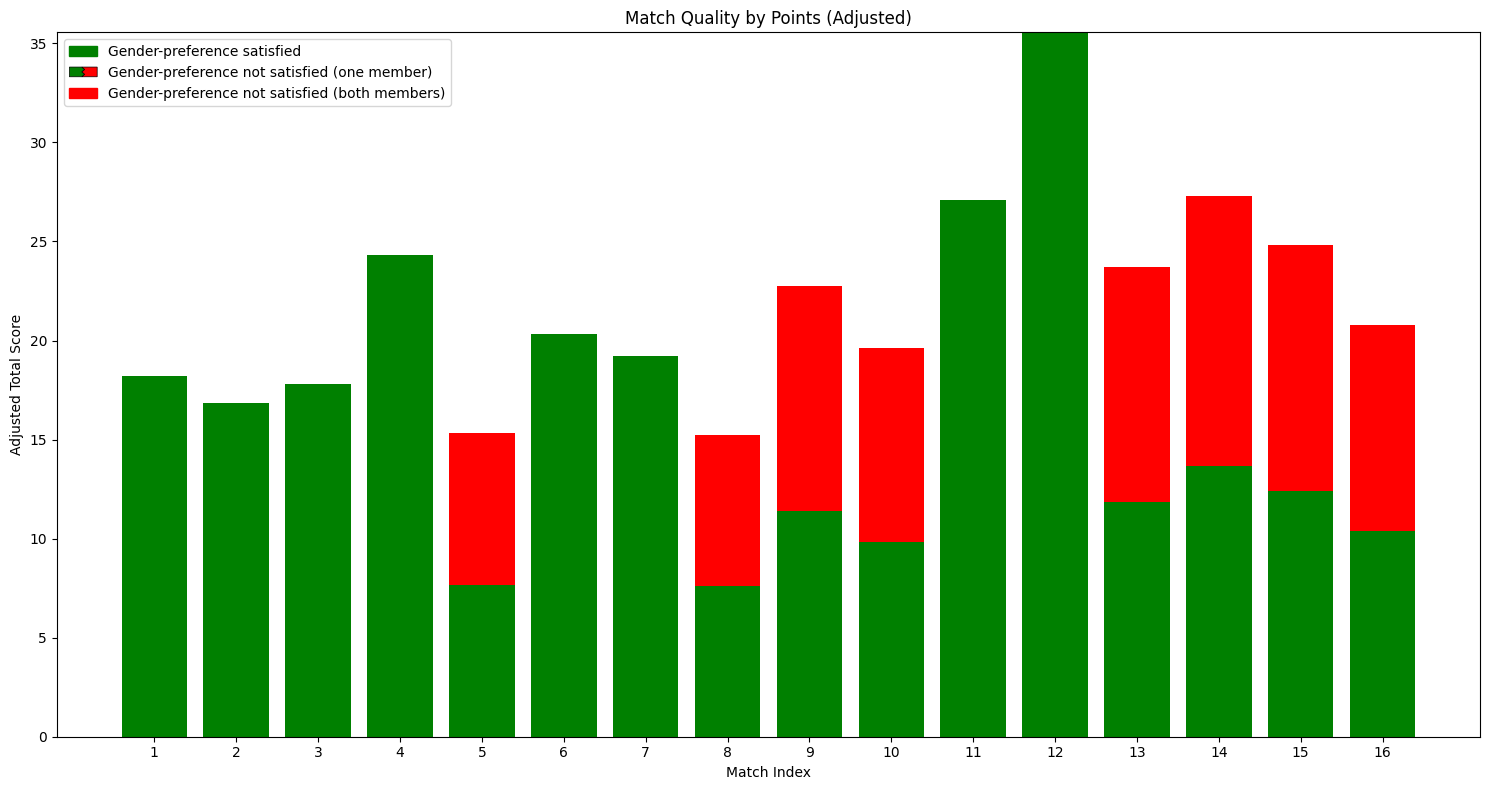

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase

# Custom legend handler for a vertically split rectangle
class HandlerZigZagSplit(HandlerBase):
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        left_color, right_color = orig_handle   # (green, red)

        x0, y0 = handlebox.xdescent, handlebox.ydescent
        w, h = handlebox.width, handlebox.height
        trans = handlebox.get_transform()

        # --- Zigzag vertical boundary coordinates ----
        # A big triangular zigzag separator inside the legend icon
        zigzag = [
            (x0 + w*0.45, y0),           # bottom start of zigzag
            (x0 + w*0.55, y0 + h*0.25),  # up
            (x0 + w*0.45, y0 + h*0.50),  # down
            (x0 + w*0.55, y0 + h*0.75),  # up
            (x0 + w*0.45, y0 + h)        # top end
        ]

        # Left polygon (GREEN side)
        left_poly = mpatches.Polygon(
            [(x0, y0), (x0 + w*0.45, y0), *zigzag, (x0, y0 + h)],
            closed=True,
            facecolor=left_color,
            edgecolor='black',
            lw=0.5,
            transform=trans
        )

        # Right polygon (RED side)
        right_poly = mpatches.Polygon(
            [*zigzag, (x0 + w, y0 + h), (x0 + w, y0)],
            closed=True,
            facecolor=right_color,
            edgecolor='black',
            lw=0.5,
            transform=trans
        )

        handlebox.add_artist(left_poly)
        handlebox.add_artist(right_poly)

        return left_poly


# Prepare data for plotting based on the new rules
green_parts = []
red_parts = []
x_labels = []

for i, (rollA, rollB, total_cost) in enumerate(final_pairs):
    x_labels.append(str(i + 1)) # Use simple index for x-axis, starting from 1

    if total_cost < 5000:
        green_parts.append(total_cost)
        red_parts.append(0)

    elif 5000 <= total_cost < 10000:
        effective_height = total_cost - 5000
        green_parts.append(effective_height / 2)
        red_parts.append(effective_height / 2)

    else:  # total_cost >= 10000
        effective_height = total_cost - 10000
        green_parts.append(0)
        red_parts.append(effective_height)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(15, 8))

ax.bar(x_labels, green_parts, color='green')
ax.bar(x_labels, red_parts, bottom=green_parts, color='red')

ax.set_title("Match Quality by Points (Adjusted)")
ax.set_xlabel("Match Index")
ax.set_ylabel("Adjusted Total Score")

# Legend
legend_handles = [
    mpatches.Patch(color='green'),
    ('green', 'red'),
    mpatches.Patch(color='red')
]

legend_labels = [
    'Gender-preference satisfied',
    'Gender-preference not satisfied (one member)',
    'Gender-preference not satisfied (both members)'
]

# IMPORTANT: instantiate the handler
handler_map = {tuple: HandlerZigZagSplit()}

ax.legend(legend_handles, legend_labels, handler_map=handler_map)

plt.tight_layout()
plt.show()


## Histogram 2 (Gender Choices Ignored for Remaining)

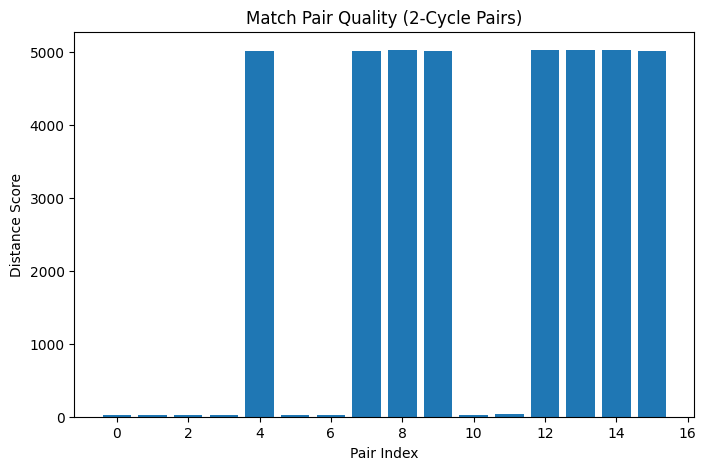

In [ ]:
pair_scores = [cost for i, j, cost in pairs]

plt.figure(figsize=(8,5))
plt.bar(range(len(pairs)), pair_scores)
plt.title("Match Pair Quality (2-Cycle Pairs)")
plt.xlabel("Pair Index")
plt.ylabel("Distance Score")
plt.show()

In [ ]:
final_pairs

[(152306, 152310, np.float64(18.22222222222222)),
 (152304, 152343, np.float64(16.833333333333332)),
 (152315, 152337, np.float64(17.8)),
 (152341, 152307, np.float64(24.333333333333336)),
 (152302, 152338, np.float64(5015.333333333334)),
 (152319, 152360, np.float64(20.333333333333336)),
 (152323, 152357, np.float64(19.2)),
 (152316, 152345, np.float64(5015.222222222222)),
 (152311, 152305, np.float64(5022.761904761904)),
 (152335, 152349, np.float64(5019.636363636364)),
 (152356, 152358, np.float64(27.07843137254902)),
 (152314, 152339, np.float64(35.55555555555556)),
 (152330, 152327, np.float64(5023.6923076923085)),
 (152346, 152301, np.float64(5027.285714285714)),
 (152308, 152313, np.float64(5024.818181818182)),
 (152340, 152325, np.float64(5020.757575757576))]

# Send Out Matches

## Match List

In [ ]:
roll_to_email = dict(zip(frame["Roll"], frame["Mail"]))

match_lines = []

for rollA, rollB, _ in final_pairs:

    # for A
    match_lines.append({
        "Roll": rollA,
        "Matched_Roll": rollB,
        "Matched_Email": roll_to_email.get(rollB, None)
    })

    # for B
    match_lines.append({
        "Roll": rollB,
        "Matched_Roll": rollA,
        "Matched_Email": roll_to_email.get(rollA, None)
    })

match_table = pd.DataFrame(match_lines)
match_table.to_csv("match_list.csv", index=False)

## Send Mails